In [2]:
import pandas as pd
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
automl = pd.read_csv("../results_download/automl_eval_results.csv")
automl.head()

,dataset,framework,few_shot,config,_runtime,accuracy,macro avg_f1-score,macro avg_precision,macro avg_recall,macro avg_support,weighted avg_f1-score,weighted avg_precision,weighted avg_recall,weighted avg_support
0,DeepPavlov/clinc150,fedot,full,"{'dataset': 'DeepPavlov/clinc150', 'framework'...",2188.463990,0.181818,0.002038,0.001204,0.006623,5500.0,0.055944,0.033058,0.181818,5500.0
1,DeepPavlov/clinc150,lama,full,"{'dataset': 'DeepPavlov/clinc150', 'framework'...",117.102701,0.181818,0.002038,0.001204,0.006623,5500.0,0.055944,0.033058,0.181818,5500.0
2,DeepPavlov/clinc150,glueon,full,"{'dataset': 'DeepPavlov/clinc150', 'framework'...",1284.465081,0.873455,0.913901,0.876267,0.963700,5500.0,0.861773,0.894271,0.873455,5500.0
3,DeepPavlov/clinc150,glueon,2,"{'dataset': 'DeepPavlov/clinc150', 'few_shot':...",93.712697,0.003818,0.000778,0.002406,0.004636,5500.0,0.000641,0.001982,0.003818,5500.0
4,DeepPavlov/clinc150,glueon,4,"{'dataset': 'DeepPavlov/clinc150', 'few_shot':...",51.414633,0.003818,0.000778,0.002406,0.004636,5500.0,0.000641,0.001982,0.003818,5500.0


In [13]:
automl = automl[(automl["framework"] == "glueon") & (automl["few_shot"] != '2')]

In [14]:
automl = automl.rename(columns={
    "macro avg_f1-score": "f1",
    # "accuracy": "accuracy",
    "macro avg_precision": "precision",
    "macro avg_recall": "recall",
})
automl = automl[["dataset", "framework", "few_shot", "f1", "precision", "recall"]]
automl

,dataset,framework,few_shot,f1,precision,recall
2,DeepPavlov/clinc150,glueon,full,0.913901,0.876267,0.963700
4,DeepPavlov/clinc150,glueon,4,0.000778,0.002406,0.004636
5,DeepPavlov/clinc150,glueon,8,0.000778,0.002406,0.004636
6,DeepPavlov/clinc150,glueon,16,0.000778,0.002406,0.004636
7,DeepPavlov/clinc150,glueon,32,0.000778,0.002406,0.004636
8,DeepPavlov/clinc150,glueon,64,0.000778,0.002406,0.004636
17,DeepPavlov/massive,glueon,full,0.877618,0.873620,0.892717
19,DeepPavlov/massive,glueon,4,0.008352,0.011365,0.019987
20,DeepPavlov/massive,glueon,8,0.008352,0.011365,0.019987
21,DeepPavlov/massive,glueon,16,0.008352,0.011365,0.019987


In [31]:
autointent = pd.read_csv("../results_download/few_shot_results.csv")
autointent.head()

,dataset,few_shot,config,_runtime,configs,decision_accuracy,decision_f1,decision_precision,decision_recall,decision_roc_auc,metrics,pipeline_metrics
0,DeepPavlov/hwu64,4,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.034076,{'decision': [{'metric_name': 'decision_accura...,0.759294,0.749508,0.764930,0.766580,0.881379,"{'decision': [0.7476901208244492, 0.4048803601...","{'decision_accuracy': 0.7592936802973977, 'dec..."
1,DeepPavlov/hwu64,8,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.207324,{'decision': [{'metric_name': 'decision_accura...,0.815056,0.808742,0.813985,0.824376,0.910720,"{'decision': [0.7848675914249684, 0.7044136191...","{'decision_accuracy': 0.8150557620817844, 'dec..."
2,DeepPavlov/hwu64,16,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.182504,{'decision': [{'metric_name': 'decision_accura...,0.841078,0.836894,0.837447,0.850721,0.924099,"{'decision': [0.8330439814814815, 0.8038194444...","{'decision_accuracy': 0.8410780669144982, 'dec..."
3,DeepPavlov/hwu64,32,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.122662,{'decision': [{'metric_name': 'decision_accura...,0.861524,0.860324,0.861766,0.865239,0.931520,"{'decision': [0.8592802264456126, 0.8152042054...","{'decision_accuracy': 0.8615241635687733, 'dec..."
4,DeepPavlov/hwu64,64,"{'regex': [], 'scoring': [{'metrics': {'scorin...",1.151558,{'decision': [{'metric_name': 'decision_accura...,0.880112,0.878294,0.880205,0.883809,0.940952,"{'decision': [0.8872767857142857, 0.8638392857...","{'decision_accuracy': 0.8801115241635687, 'dec..."


In [32]:
autointent["dataset"].value_counts()

dataset
DeepPavlov/hwu64      7
DeepPavlov/minds14    7
DeepPavlov/snips      7
Name: count, dtype: int64

In [34]:
autointent = autointent.rename(columns={
    "decision_accuracy": "accuracy",
    "decision_f1": "f1",
    "decision_precision": "precision",
    "decision_recall": "recall",
})
autointent = autointent[["dataset", "few_shot", "f1", "precision", "recall", "accuracy"]]
autointent

,dataset,few_shot,f1,precision,recall,accuracy
0,DeepPavlov/hwu64,4,0.749508,0.764930,0.766580,0.759294
1,DeepPavlov/hwu64,8,0.808742,0.813985,0.824376,0.815056
2,DeepPavlov/hwu64,16,0.836894,0.837447,0.850721,0.841078
3,DeepPavlov/hwu64,32,0.860324,0.861766,0.865239,0.861524
4,DeepPavlov/hwu64,64,0.878294,0.880205,0.883809,0.880112
5,DeepPavlov/hwu64,128,0.877157,0.879999,0.882057,0.876394
6,DeepPavlov/hwu64,full,0.879904,0.882321,0.884631,0.881041
7,DeepPavlov/minds14,4,0.931045,0.942460,0.936650,0.935185
8,DeepPavlov/minds14,8,0.948169,0.957341,0.950255,0.953704
9,DeepPavlov/minds14,16,0.943978,0.957341,0.950255,0.953704


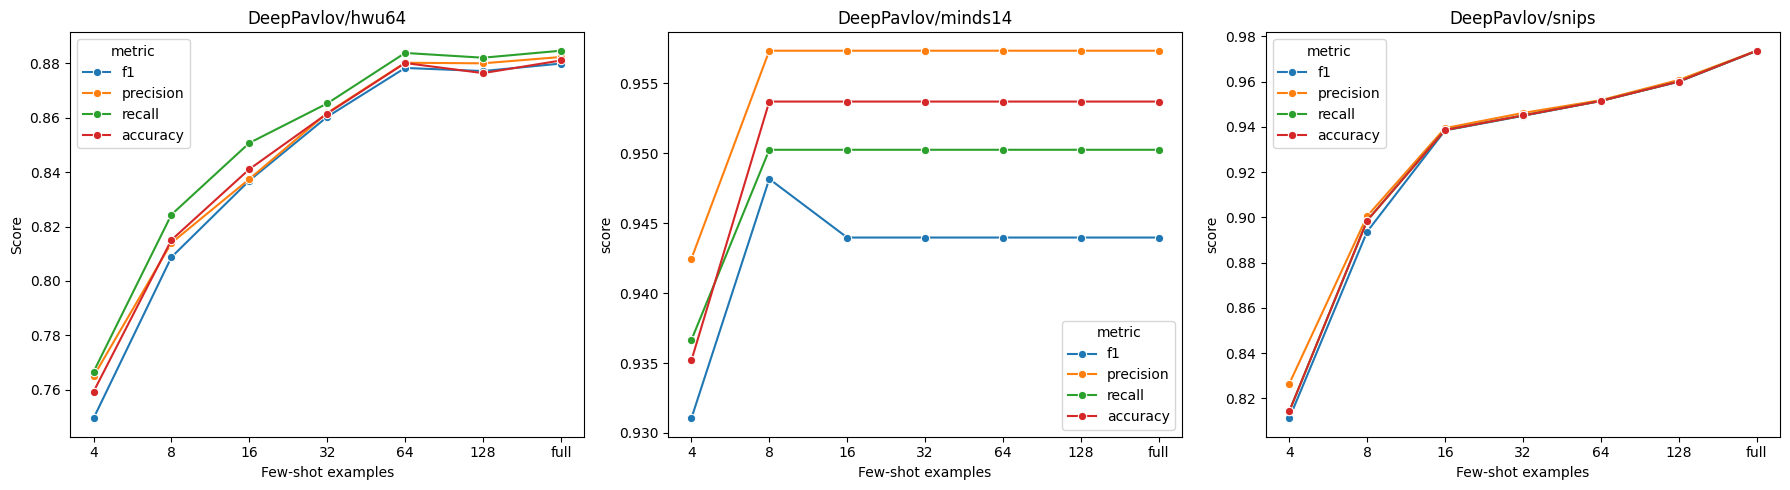

In [36]:
# ...existing code...

# Plot few-shot performance for each dataset (F1, Precision, Recall on same axes)
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data: drop 'full', cast few_shot to int
df_plot = autointent.copy()
df_plot.loc[df_plot['few_shot'] == 'full', 'few_shot'] = '256'
# df_plot = df_plot[df_plot['few_shot'] != '256']
df_plot['few_shot'] = df_plot['few_shot'].astype(int)

# Determine unique datasets
datasets = df_plot['dataset'].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(18, 5), sharey=False)

# Define few-shot ticks including 256
xticks = [4, 8, 16, 32, 64, 128, 256]
xticks_labels = [4, 8, 16, 32, 64, 128, 'full']

for ax, ds in zip(axes, datasets):
    sub = df_plot[df_plot['dataset'] == ds]
    sub_melt = sub.melt(
        id_vars='few_shot',
        value_vars=['f1', 'precision', 'recall', 'accuracy'],
        var_name='metric',
        value_name='score'
    )
    sns.lineplot(
        data=sub_melt,
        x='few_shot', y='score',
        hue='metric', marker='o', ax=ax
    )
    ax.set_xscale('log', base=2)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks_labels)
    ax.set_title(ds)
    ax.set_xlabel('Few‐shot examples')
axes[0].set_ylabel('Score')

fig.tight_layout()
plt.show()

In [15]:
automl

,dataset,framework,few_shot,f1,precision,recall
2,DeepPavlov/clinc150,glueon,full,0.913901,0.876267,0.963700
4,DeepPavlov/clinc150,glueon,4,0.000778,0.002406,0.004636
5,DeepPavlov/clinc150,glueon,8,0.000778,0.002406,0.004636
6,DeepPavlov/clinc150,glueon,16,0.000778,0.002406,0.004636
7,DeepPavlov/clinc150,glueon,32,0.000778,0.002406,0.004636
8,DeepPavlov/clinc150,glueon,64,0.000778,0.002406,0.004636
17,DeepPavlov/massive,glueon,full,0.877618,0.873620,0.892717
19,DeepPavlov/massive,glueon,4,0.008352,0.011365,0.019987
20,DeepPavlov/massive,glueon,8,0.008352,0.011365,0.019987
21,DeepPavlov/massive,glueon,16,0.008352,0.011365,0.019987
